In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
from pathlib import Path
import sys
import pandas as pd
import matplotlib.pyplot as plt

# ===== 1. Make repo importable =====
# 假设 notebook 在: CS50-analysis/tests/Harmonic_pattern_demo.ipynb
REPO_ROOT = Path.cwd().resolve().parents[0]
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

print("REPO_ROOT =", REPO_ROOT)

from stock_analysis.config import SLD_WINDOW_CONFIG

REPO_ROOT = C:\Users\17866\OneDrive\桌面\Ltq\2026a\data5703\project\work\current_work\CS50-analysis


## Import the data

In [2]:
# path
data_path = REPO_ROOT / "TestData" / "stock_daily_OHLC_long.csv"


df = pd.read_csv(data_path)
print(df.head())

     Datetime Ticker        Open        High         Low       Close
0  2022-05-16   AAPL  145.550003  147.520004  144.179993  145.539993
1  2022-05-17   AAPL  148.860001  149.770004  146.679993  149.240005
2  2022-05-18   AAPL  146.850006  147.360001  139.899994  140.820007
3  2022-05-19   AAPL  139.880005  141.660004  136.600006  137.350006
4  2022-05-20   AAPL  139.089996  140.699997  132.610001  137.589996


In [3]:
df_aapl = df[df["Ticker"] == "AAPL"].copy()
df_aapl = df_aapl.sort_values("Datetime").reset_index(drop=True)
print(df_aapl.shape)
df_aapl.head()

(1000, 6)


,Datetime,Ticker,Open,High,Low,Close
0,2022-05-16,AAPL,145.550003,147.520004,144.179993,145.539993
1,2022-05-17,AAPL,148.860001,149.770004,146.679993,149.240005
2,2022-05-18,AAPL,146.850006,147.360001,139.899994,140.820007
3,2022-05-19,AAPL,139.880005,141.660004,136.600006,137.350006
4,2022-05-20,AAPL,139.089996,140.699997,132.610001,137.589996


## Tools Function Initialization

harmonic detector

In [4]:
import pkgutil
import importlib
import inspect

from stock_analysis.base import BasePattern
import stock_analysis.harmonic_patterns as harmonic_pkg


def load_harmonic_detectors():
    detectors = []

    for _, module_name, _ in pkgutil.iter_modules(harmonic_pkg.__path__):
        full_module_name = f"{harmonic_pkg.__name__}.{module_name}"
        module = importlib.import_module(full_module_name)

        for _, obj in inspect.getmembers(module, inspect.isclass):
            if issubclass(obj, BasePattern) and obj is not BasePattern:
                if getattr(obj, "enabled", False):
                    try:
                        detectors.append(obj())
                    except Exception as e:
                        print(f"Skip detector {obj.__name__}: {e}")

    return detectors


harmonic_detectors = load_harmonic_detectors()

print(f"Loaded {len(harmonic_detectors)} harmonic detectors:")
for d in harmonic_detectors:
    print("-", d.__class__.__name__)

Loaded 7 harmonic detectors:
- BatHarmonicPattern
- ButterflyHarmonicPattern
- CrabHarmonicPattern
- CypherHarmonicPattern
- GartleyHarmonicPattern
- DummyHarmonicPattern
- SharkHarmonicPattern


In [5]:
def run_detector(detector, df_window: pd.DataFrame) -> dict | None:
    """
    Run one chart detector safely.
    Returns the detector result dict or None if failed.
    """
    try:
        if hasattr(detector, "_run"):
            result = detector._run(df_window)
        elif hasattr(detector, "run"):
            result = detector.run(df_window)
        else:
            return None

        if not isinstance(result, dict):
            return None

        return result

    except Exception as e:
        # first version: just skip failures
        return None

pre trend

In [6]:
from stock_analysis.trendanalysis import TrendAnalysis

trend_analyzer = TrendAnalysis()

In [7]:
def project_pretrend_analysis(df_window: pd.DataFrame) -> dict:
    trend = trend_analyzer.pre_trend_analysis(df_window)
    if trend is None:
        return {
            "label": "unknown",
            "strength": 0.0,
            "higher_high_ratio": 0.0,
            "higher_low_ratio": 0.0,
            "lower_high_ratio": 0.0,
            "lower_low_ratio": 0.0,
            "candles": len(df_window),
        }
    return trend

In [8]:
HARMONIC_PATTERN_WINDOW_SIZE = {
    "GartleyHarmonicPattern": 200,
    "BatHarmonicPattern": 200,
    "ButterflyHarmonicPattern": 200,
    "CrabHarmonicPattern": 200,
    "CypherHarmonicPattern": 200,
    "SharkHarmonicPattern": 200,
}

In [9]:
def is_valid_harmonic_signal(result: dict, min_confidence: float = 60) -> bool:
    if not result:
        return False

    if not result.get("confirmed", False):
        return False

    if result.get("confidence", 0) < min_confidence:
        return False

    if result.get("direction") not in {"bullish", "bearish"}:
        return False

    return True

formation

In [10]:
def collect_harmonic_formations_at_t(
    df_hist,
    detectors,
    recent_windows_per_pattern=2,
    min_confidence=60,
):

    formations = []

    for detector in detectors:
        pattern_name = detector.__class__.__name__
        window_size = HARMONIC_PATTERN_WINDOW_SIZE.get(pattern_name, 200)

        if len(df_hist) < window_size:
            continue

        for window_count in range(1, recent_windows_per_pattern + 1):
            end_idx = len(df_hist) - (window_count - 1)
            start_idx = end_idx - window_size

            if start_idx < 0:
                continue

            df_window = df_hist.iloc[start_idx:end_idx].reset_index(drop=True)

            result = run_detector(detector, df_window)

            if not is_valid_harmonic_signal(result, min_confidence):
                continue

            formation = {
                "pattern": pattern_name,
                "confidence": result.get("confidence", 0),
                "window_count": window_count,
                "window_size": window_size,
                "current_time": df_window["Datetime"].iloc[-1],
                "pre_trend": project_pretrend_analysis(df_window),  # ⭐关键
                "signal": {
                    "direction": result.get("direction"),
                    "pivots": result.get("pivots", []),
                },
                "raw_result": result,
            }

            formations.append(formation)

    return formations

## Back Test

In [11]:
from stock_analysis.context_scores.harmonic_score import harmonic_score as harmonic_context_score
import numpy as np
import pandas as pd


def find_harmonic_confirmation_index(
    df: pd.DataFrame,
    t: int,
    bias: str,
    confirm_window: int = 10,
    confirm_threshold: float = 0.005,
) -> int | None:
    """
    Find first confirmation point after harmonic context appears.

    bullish:
        close rises by confirm_threshold from current close
    bearish:
        close falls by confirm_threshold from current close
    """

    if bias not in {"bullish", "bearish"}:
        return None

    if t >= len(df) - 1:
        return None

    current_close = df.iloc[t]["Close"]

    end = min(t + confirm_window, len(df) - 1)

    for i in range(t + 1, end + 1):
        close_i = df.iloc[i]["Close"]
        move = (close_i - current_close) / max(abs(current_close), 1e-9)

        if bias == "bullish" and move >= confirm_threshold:
            return i

        if bias == "bearish" and move <= -confirm_threshold:
            return i

    return None

In [12]:
def backtest_harmonic_context_score_confirmed(
    df,
    detectors,
    min_history=200,
    future_horizon=30,
    recent_windows_per_pattern=2,
    return_lookback=30,
    min_confidence=60,
    confirm_window=10,
    confirm_threshold=0.005,
):

    records = []
    start_t = max(min_history, return_lookback)

    # Need enough room for confirmation window + future horizon
    end_t = len(df) - confirm_window - future_horizon

    for t in range(start_t, end_t):
        df_hist = df.iloc[:t + 1].copy()

        past_row = df.iloc[t - return_lookback]
        current_row = df.iloc[t]

        formations = collect_harmonic_formations_at_t(
            df_hist=df_hist,
            detectors=detectors,
            recent_windows_per_pattern=recent_windows_per_pattern,
            min_confidence=min_confidence,
        )

        ctx = harmonic_context_score(formations)

        past_close = past_row["Close"]
        current_close = current_row["Close"]

        recent_return = (current_close - past_close) / max(abs(past_close), 1e-9)

        bias = ctx["bias"]

        confirm_idx = find_harmonic_confirmation_index(
            df=df,
            t=t,
            bias=bias,
            confirm_window=confirm_window,
            confirm_threshold=confirm_threshold,
        )

        if confirm_idx is not None:
            confirm_row = df.iloc[confirm_idx]
            future_row = df.iloc[confirm_idx + future_horizon]

            confirm_close = confirm_row["Close"]
            future_close = future_row["Close"]

            future_return = (
                future_close - confirm_close
            ) / max(abs(confirm_close), 1e-9)

            if bias == "bullish":
                future_correct = int(future_return > 0)
            elif bias == "bearish":
                future_correct = int(future_return < 0)
            else:
                future_correct = np.nan

            confirmed = True
            confirmation_delay = confirm_idx - t
            confirmation_time = confirm_row["Datetime"]
        else:
            future_return = np.nan
            future_correct = np.nan
            future_close = np.nan
            confirm_close = np.nan
            confirmed = False
            confirmation_delay = np.nan
            confirmation_time = pd.NaT

        # For harmonic, recent setup is expected to be opposite to bias
        if bias == "bullish":
            recent_setup_correct = int(recent_return < 0)
        elif bias == "bearish":
            recent_setup_correct = int(recent_return > 0)
        else:
            recent_setup_correct = np.nan

        records.append({
            "t": t,
            "Datetime": current_row["Datetime"],

            "score": ctx["score"],
            "bias": bias,
            "agreement": ctx["agreement"],
            "bull_score": ctx["bull_score"],
            "bear_score": ctx["bear_score"],
            "pattern_count": ctx["pattern_count"],

            "recent_return": recent_return,
            "recent_setup_correct": recent_setup_correct,

            "confirmed": confirmed,
            "confirmation_delay": confirmation_delay,
            "confirmation_time": confirmation_time,
            "confirm_close": confirm_close,

            "future_return": future_return,
            "future_close": future_close,
            "future_correct": future_correct,

            "current_close": current_close,
            "past_close": past_close,

            "formations": formations,
            "context_detail": ctx,
        })

    return pd.DataFrame(records)

In [13]:
tickers = [
    "AAPL", "MSFT", "NVDA", "TSLA", "GOOGL",
    "AMZN", "META", "JPM", "BAC", "GS"
]

In [14]:
all_results = []

for ticker in tickers:
    print(f"\nRunning harmonic backtest for {ticker}...")

    df_ticker = (
        df[df["Ticker"] == ticker]
        .copy()
        .sort_values("Datetime")
        .reset_index(drop=True)
    )

    if len(df_ticker) < 250:
        print(f"{ticker}: skipped, not enough data")
        continue

    try:
        result = backtest_harmonic_context_score_confirmed(
            df=df_ticker,
            detectors=harmonic_detectors,
            min_history=252,
            future_horizon=126,
            recent_windows_per_pattern=100,
            return_lookback=126,
            min_confidence=0,
            confirm_window=30,
            confirm_threshold=0.03,
        )

        if result.empty:
            print(f"{ticker}: empty result")
            continue

        result["Ticker"] = ticker
        all_results.append(result)

        print(f"{ticker}: done, rows = {len(result)}")

    except Exception as e:
        print(f"{ticker}: failed -> {e}")

harmonic_backtest_all = pd.concat(all_results, ignore_index=True)

print("\nAll harmonic backtest results:")
print(harmonic_backtest_all.shape)
harmonic_backtest_all.head()


Running harmonic backtest for AAPL...
AAPL: done, rows = 592

Running harmonic backtest for MSFT...
MSFT: done, rows = 592

Running harmonic backtest for NVDA...
NVDA: done, rows = 592

Running harmonic backtest for TSLA...
TSLA: done, rows = 592

Running harmonic backtest for GOOGL...
GOOGL: done, rows = 592

Running harmonic backtest for AMZN...
AMZN: done, rows = 592

Running harmonic backtest for META...
META: done, rows = 592

Running harmonic backtest for JPM...
JPM: done, rows = 592

Running harmonic backtest for BAC...
BAC: done, rows = 592

Running harmonic backtest for GS...
GS: done, rows = 592

All harmonic backtest results:
(5920, 22)


,t,Datetime,score,bias,agreement,bull_score,bear_score,pattern_count,recent_return,recent_setup_correct,...,confirmation_time,confirm_close,future_return,future_close,future_correct,current_close,past_close,formations,context_detail,Ticker
0,252,2023-05-17,-0.568,bearish,1.0,0.0,100.0,34,0.164621,1.0,...,NaT,NaN,NaN,NaN,NaN,172.690002,148.279999,"[{'pattern': 'CypherHarmonicPattern', 'confide...","{'score': -0.568, 'bias': 'bearish', 'agreemen...",AAPL
1,253,2023-05-18,-0.568,bearish,1.0,0.0,100.0,35,0.166689,1.0,...,NaT,NaN,NaN,NaN,NaN,175.050003,150.039993,"[{'pattern': 'CypherHarmonicPattern', 'confide...","{'score': -0.568, 'bias': 'bearish', 'agreemen...",AAPL
2,254,2023-05-19,-0.568,bearish,1.0,0.0,100.0,36,0.177230,1.0,...,NaT,NaN,NaN,NaN,NaN,175.160004,148.789993,"[{'pattern': 'CypherHarmonicPattern', 'confide...","{'score': -0.568, 'bias': 'bearish', 'agreemen...",AAPL
3,255,2023-05-22,-0.568,bearish,1.0,0.0,100.0,37,0.155786,1.0,...,NaT,NaN,NaN,NaN,NaN,174.199997,150.720001,"[{'pattern': 'CypherHarmonicPattern', 'confide...","{'score': -0.568, 'bias': 'bearish', 'agreemen...",AAPL
4,256,2023-05-23,-0.568,bearish,1.0,0.0,100.0,38,0.133981,1.0,...,NaT,NaN,NaN,NaN,NaN,171.559998,151.289993,"[{'pattern': 'CypherHarmonicPattern', 'confide...","{'score': -0.568, 'bias': 'bearish', 'agreemen...",AAPL


## Visualization

In [15]:
corr_records = []

for ticker, group in harmonic_backtest_all.groupby("Ticker"):
    temp = group[["score", "recent_return", "future_return"]].dropna()

    if len(temp) < 10:
        print(f"{ticker}: skipped correlation, too few valid rows")
        continue

    recent_corr = temp["score"].corr(temp["recent_return"])
    future_corr = temp["score"].corr(temp["future_return"])

    corr_records.append({
        "Ticker": ticker,
        "Recent_Return_Corr": recent_corr,
        "Future_Return_Corr": future_corr,
        "N": len(temp),
    })

harmonic_corr_df = pd.DataFrame(corr_records)
harmonic_corr_df

,Ticker,Recent_Return_Corr,Future_Return_Corr,N
0,AAPL,-0.305219,0.000606,255
1,AMZN,-0.678913,-0.177035,362
2,BAC,-0.140614,0.159838,331
3,GOOGL,0.059902,-0.682663,344
4,GS,0.267029,-0.559148,285
5,JPM,-0.763675,0.053080,265
6,META,-0.300514,-0.629935,252
7,MSFT,-0.575111,0.001149,402
8,NVDA,-0.605331,0.128019,369
9,TSLA,0.109509,-0.310306,441


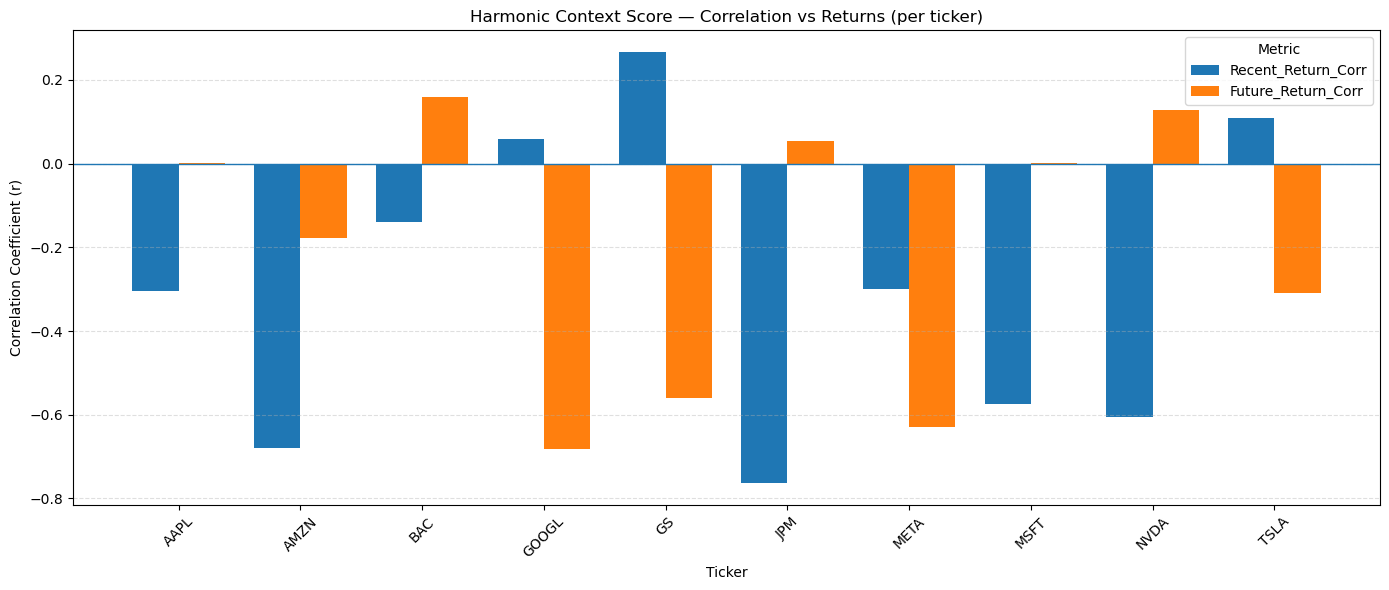

In [16]:
import matplotlib.pyplot as plt
import numpy as np

plot_df = harmonic_corr_df.sort_values("Ticker").reset_index(drop=True)

x = np.arange(len(plot_df))
width = 0.38

plt.figure(figsize=(14, 6))

plt.bar(
    x - width / 2,
    plot_df["Recent_Return_Corr"],
    width,
    label="Recent_Return_Corr"
)

plt.bar(
    x + width / 2,
    plot_df["Future_Return_Corr"],
    width,
    label="Future_Return_Corr"
)

plt.axhline(0, linewidth=1)

plt.xticks(x, plot_df["Ticker"], rotation=45)
plt.ylabel("Correlation Coefficient (r)")
plt.xlabel("Ticker")
plt.title("Harmonic Context Score — Correlation vs Returns (per ticker)")
plt.legend(title="Metric")
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

In [17]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np
import pandas as pd

metric_records = []

for ticker, group in harmonic_backtest_all.groupby("Ticker"):
    temp = group[group["bias"].isin(["bullish", "bearish"])].copy()

    # future metrics 只用 confirmed rows
    temp_future = temp[temp["confirmed"] == True].dropna(subset=["future_return"]).copy()

    if len(temp) < 10:
        print(f"{ticker}: skipped recent metrics, too few directional rows")
        continue

    # =========================
    # Recent setup direction
    # bullish harmonic expects previous decline
    # bearish harmonic expects previous rise
    # =========================
    temp["recent_true"] = np.where(temp["recent_return"] > 0, 1, 0)

    # recent prediction:
    # bullish harmonic predicts recent setup should be negative -> 0
    # bearish harmonic predicts recent setup should be positive -> 1
    temp["recent_pred"] = np.where(temp["bias"] == "bearish", 1, 0)

    recent_accuracy = accuracy_score(temp["recent_true"], temp["recent_pred"])
    recent_precision = precision_score(temp["recent_true"], temp["recent_pred"], zero_division=0)
    recent_recall = recall_score(temp["recent_true"], temp["recent_pred"], zero_division=0)
    recent_f1 = f1_score(temp["recent_true"], temp["recent_pred"], zero_division=0)

    # =========================
    # Future direction after confirmation
    # bullish harmonic predicts future rise
    # bearish harmonic predicts future fall
    # =========================
    if len(temp_future) >= 10:
        temp_future["future_true"] = np.where(temp_future["future_return"] > 0, 1, 0)
        temp_future["future_pred"] = np.where(temp_future["bias"] == "bullish", 1, 0)

        future_accuracy = accuracy_score(temp_future["future_true"], temp_future["future_pred"])
        future_precision = precision_score(temp_future["future_true"], temp_future["future_pred"], zero_division=0)
        future_recall = recall_score(temp_future["future_true"], temp_future["future_pred"], zero_division=0)
        future_f1 = f1_score(temp_future["future_true"], temp_future["future_pred"], zero_division=0)
    else:
        future_accuracy = np.nan
        future_precision = np.nan
        future_recall = np.nan
        future_f1 = np.nan

    metric_records.append({
        "Ticker": ticker,

        "Recent_Accuracy": recent_accuracy,
        "Future_Accuracy": future_accuracy,

        "Recent_Precision": recent_precision,
        "Future_Precision": future_precision,

        "Recent_Recall": recent_recall,
        "Future_Recall": future_recall,

        "Recent_F1": recent_f1,
        "Future_F1": future_f1,

        "N_Recent": len(temp),
        "N_Future_Confirmed": len(temp_future),
        "Confirmation_Rate": len(temp_future) / len(temp) if len(temp) > 0 else np.nan,
    })

harmonic_metric_df = pd.DataFrame(metric_records)
harmonic_metric_df

,Ticker,Recent_Accuracy,Future_Accuracy,Recent_Precision,Future_Precision,Recent_Recall,Future_Recall,Recent_F1,Future_F1,N_Recent,N_Future_Confirmed,Confirmation_Rate
0,AAPL,0.506112,0.498039,0.870588,0.672840,0.451220,0.592391,0.594378,0.630058,409,255,0.623472
1,AMZN,0.871972,0.406077,0.946352,0.970297,0.900000,0.316129,0.922594,0.476886,578,362,0.626298
2,BAC,0.616056,0.220544,0.707566,0.971014,0.817967,0.207430,0.758772,0.341837,573,331,0.577661
3,GOOGL,0.461149,0.279070,0.752187,0.521978,0.524390,0.371094,0.617964,0.433790,592,344,0.581081
4,GS,0.656846,0.094737,0.768763,0.428571,0.818575,0.108434,0.792887,0.173077,577,285,0.493934
5,JPM,0.768939,0.279245,1.000000,1.000000,0.768061,0.276515,0.868817,0.433234,528,265,0.501894
6,META,0.995859,0.214286,0.995859,0.000000,1.000000,0.000000,0.997925,0.000000,483,252,0.521739
7,MSFT,0.581081,0.549751,0.927798,0.767635,0.529897,0.596774,0.674541,0.671506,592,402,0.679054
8,NVDA,0.954198,0.214092,0.958592,1.000000,0.991435,0.123867,0.974737,0.220430,524,369,0.704198
9,TSLA,0.415541,0.380952,0.556430,0.509317,0.544987,0.297101,0.550649,0.375286,592,441,0.744932


In [18]:
def plot_recent_future_metric(metric_df, metric_name, title_prefix="Harmonic Context Score"):
    plot_df = metric_df.sort_values("Ticker").reset_index(drop=True)

    recent_col = f"Recent_{metric_name}"
    future_col = f"Future_{metric_name}"

    x = np.arange(len(plot_df))
    width = 0.38

    plt.figure(figsize=(14, 6))

    plt.bar(
        x - width / 2,
        plot_df[recent_col],
        width,
        label=recent_col
    )

    plt.bar(
        x + width / 2,
        plot_df[future_col],
        width,
        label=future_col
    )

    plt.xticks(x, plot_df["Ticker"], rotation=45)
    plt.ylabel(metric_name)
    plt.xlabel("Ticker")
    plt.title(f"{title_prefix} — {metric_name}")
    plt.ylim(0, 1)

    plt.legend(title="Metric")
    plt.grid(axis="y", linestyle="--", alpha=0.4)

    plt.tight_layout()
    plt.show()

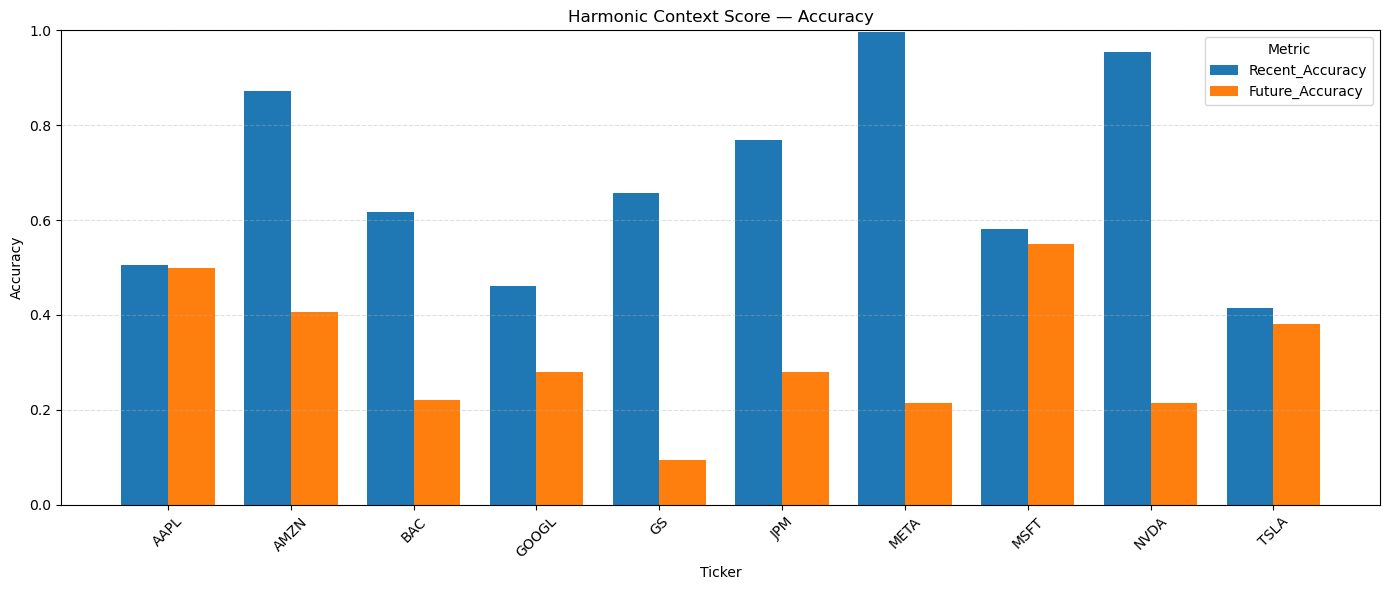

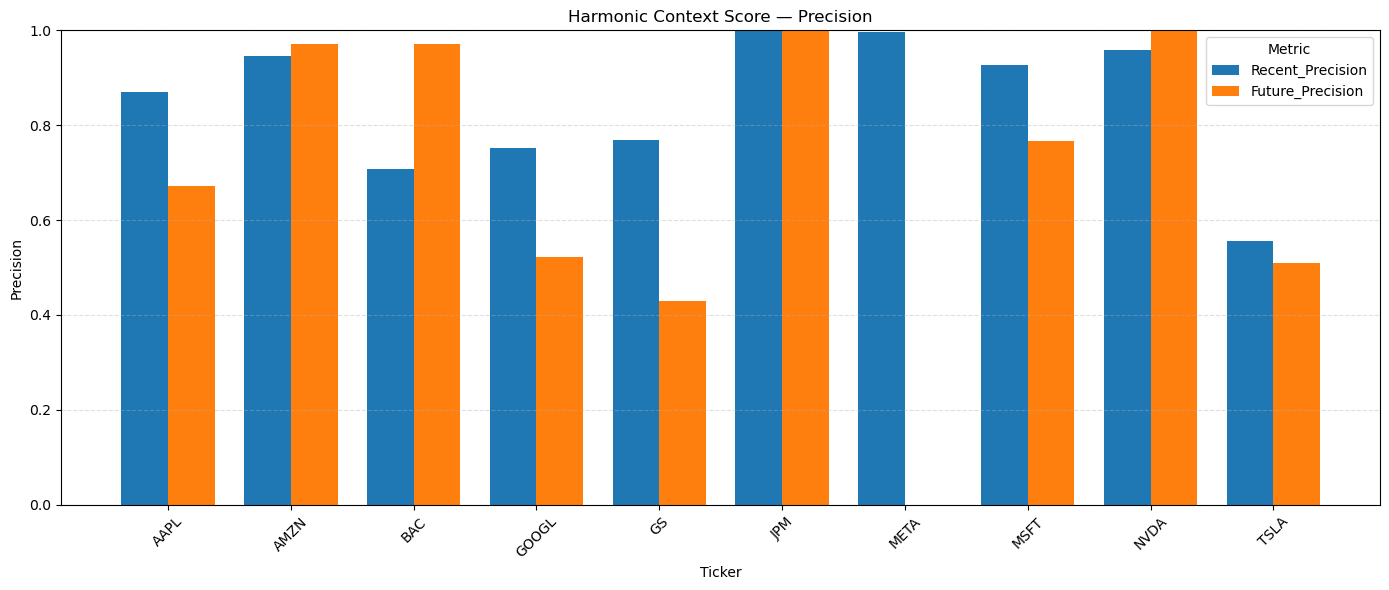

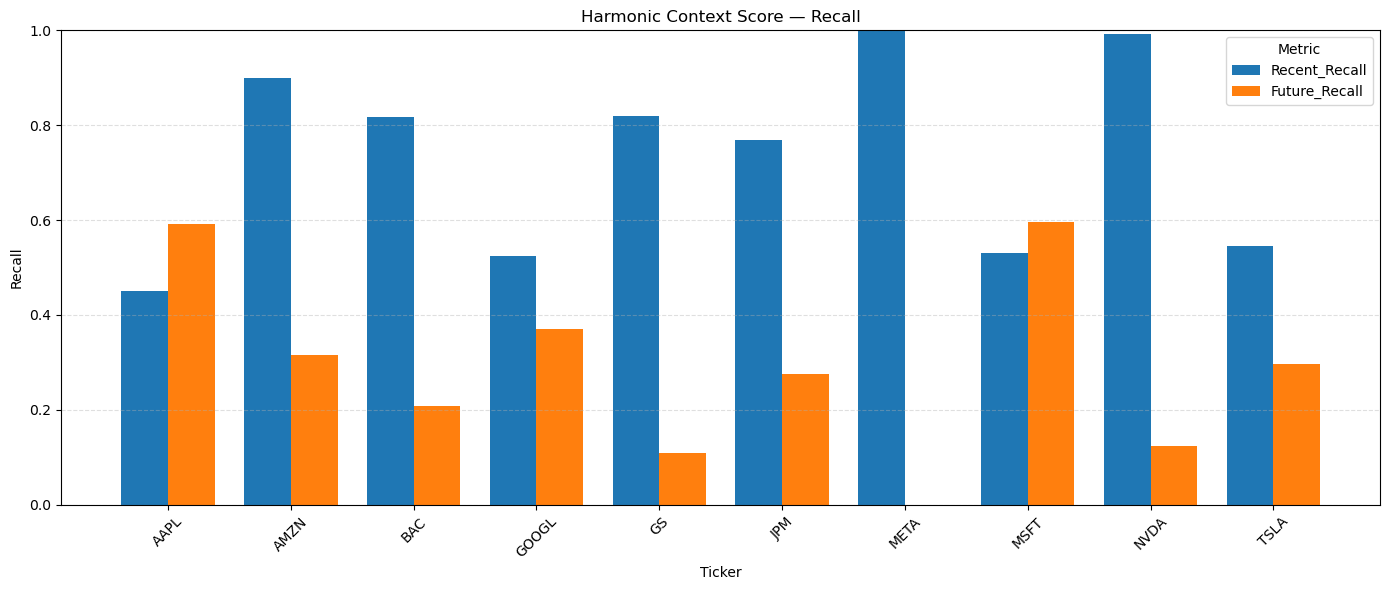

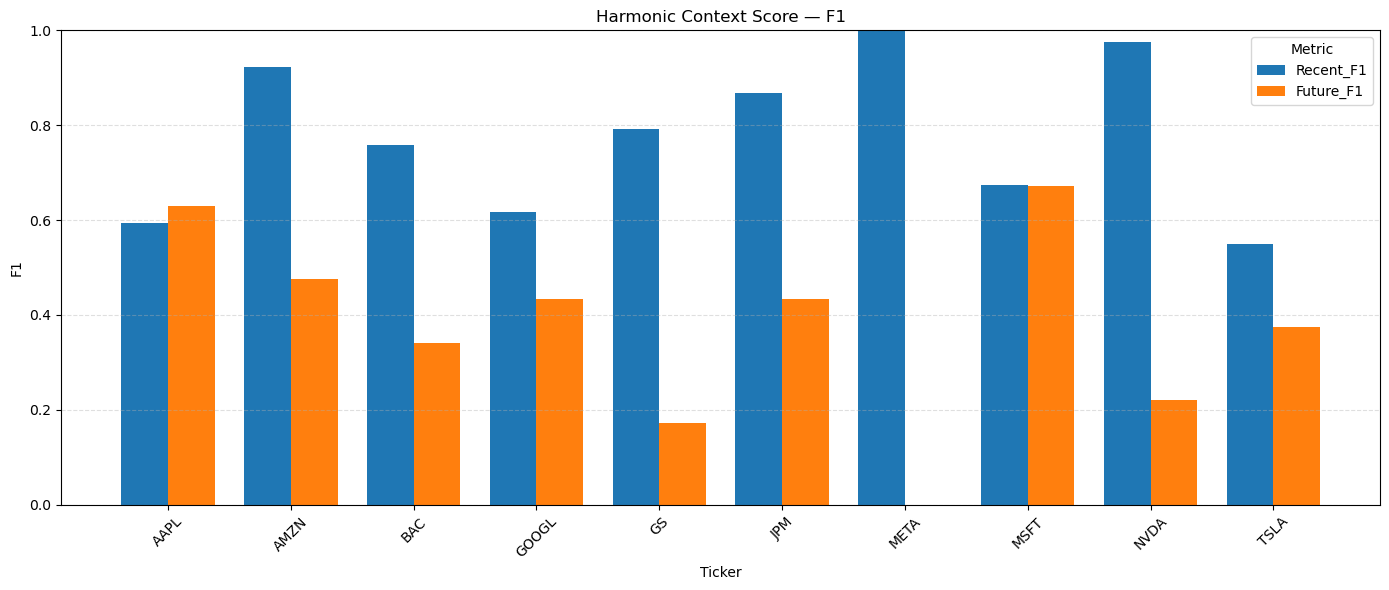

In [19]:
plot_recent_future_metric(harmonic_metric_df, "Accuracy")
plot_recent_future_metric(harmonic_metric_df, "Precision")
plot_recent_future_metric(harmonic_metric_df, "Recall")
plot_recent_future_metric(harmonic_metric_df, "F1")

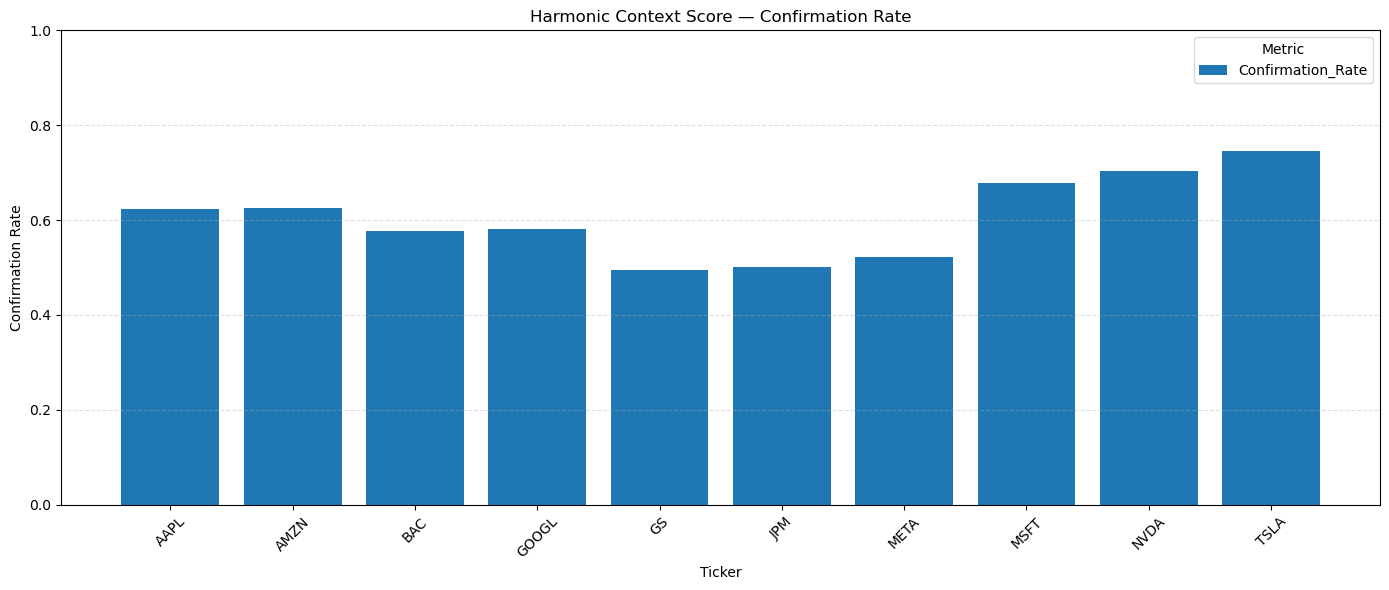

In [20]:
plot_df = harmonic_metric_df.sort_values("Ticker").reset_index(drop=True)

x = np.arange(len(plot_df))

plt.figure(figsize=(14, 6))

plt.bar(
    x,
    plot_df["Confirmation_Rate"],
    label="Confirmation_Rate"
)

plt.xticks(x, plot_df["Ticker"], rotation=45)
plt.ylabel("Confirmation Rate")
plt.xlabel("Ticker")
plt.title("Harmonic Context Score — Confirmation Rate")
plt.ylim(0, 1)
plt.legend(title="Metric")
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()